In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class LoadLabelsDataset(Dataset):
    def __init__(self, label_paths, target_transform=None):
        self.label_paths = label_paths
        self.target_transform = target_transform
        
    def __len__(self):
        return len(self.label_paths)
    
    def __getitem__(self, idx):
        lbl_path = self.label_paths[idx]
        label = Image.open(lbl_path).convert('L')
        
        if self.target_transform:
            label = self.target_transform(label)
        
        return label

In [ ]:
import os

dataset_root = os.path.join(os.path.dirname(os.getcwd()), 'data', 'Mural_seg_processed')
train_dir = os.path.join(dataset_root, "train")
val_dir = os.path.join(dataset_root, "val")
test_dir = os.path.join(dataset_root, "test")

def load_labels(data_dir):
    labels_dir = os.path.join(data_dir, "labels")
    label_files = sorted([f for f in os.listdir(labels_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    label_paths = [os.path.join(labels_dir, f) for f in label_files]
    return label_paths

train_labels = load_labels(train_dir)
val_labels = load_labels(val_dir)
test_labels = load_labels(test_dir)

print(f"Train Labels: {len(train_labels)}")
print(f"Val Labels:   {len(val_labels)}")
print(f"Test Labels:  {len(test_labels)}")

Train Labels: 760 labels
Val Labels:   100 labels
Test Labels:  101 labels


In [ ]:
label_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

train_dataset = LoadLabelsDataset(train_labels, target_transform=label_transforms)
val_dataset = LoadLabelsDataset(val_labels, target_transform=label_transforms)
test_dataset = LoadLabelsDataset(test_labels, target_transform=label_transforms)

BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoader Config: Batch Size = {BATCH_SIZE}")
data_iter = iter(train_loader)
labels = next(data_iter)

print(f"Train Batch Shape: {labels.shape}")
print(f"Train Batch Range: Min={labels.min():.4f}, Max={labels.max():.4f}")
print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Val Dataset Size:   {len(val_dataset)}")
print(f"Test Dataset Size:  {len(test_dataset)}")

DataLoader 配置: Batch Size = 8
Train Batch 标签形状: torch.Size([8, 1, 256, 256])
Train Batch 标签范围: Min=0.0000, Max=1.0000
Train Dataset Size: 760
Val Dataset Size:   100
Test Dataset Size:  101


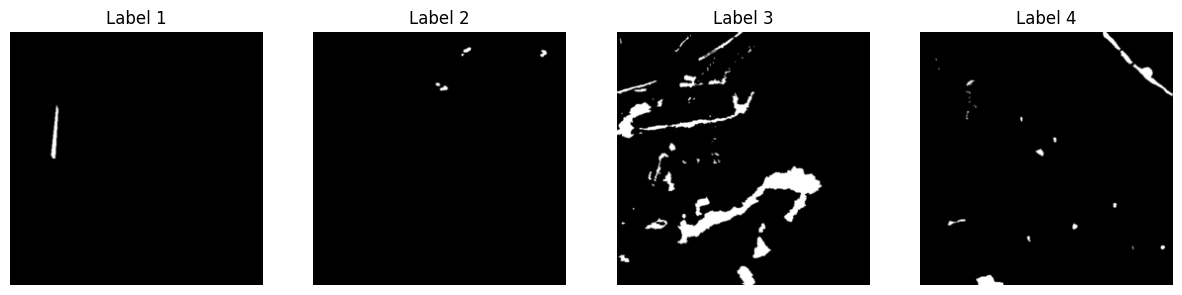

In [ ]:
import matplotlib.pyplot as plt

def show_labels(labels, num_images=4):
    labels = labels[:num_images]
    labels = labels.squeeze(1)
    
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        axes[i].imshow(labels[i].cpu(), cmap='gray')
        axes[i].set_title(f'Label {i+1}')
        axes[i].axis('off')
    plt.show()

show_labels(labels)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        
        self.fc_mu = nn.Linear(128 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(128 * 16 * 16, latent_dim)
        
        self.decoder_input = nn.Linear(latent_dim, 128 * 16 * 16)
        
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 16, 16)),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1),
            nn.Sigmoid() 
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        
        r = self.decoder_input(z)
        recon = self.decoder(r)
        return recon, mu, logvar

def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = VAE(latent_dim=32).to(device)
print(model)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=32768, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=32768, out_features=128, bias=True)
  (decoder_input): Linear(in_features=128, out_features=32768, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(128, 16, 16))
    (1): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2)

In [ ]:
from tqdm import tqdm
import numpy as np

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
num_epochs = 100

early_stopping = EarlyStopping(patience=10, min_delta=0.1)

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        labels = labels.to(device)
        optimizer.zero_grad()
        
        recon_labels, mu, logvar = model(labels)
        loss = loss_function(recon_labels, labels, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    
    avg_train_loss = train_loss / len(train_loader.dataset)
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for labels in val_loader:
            labels = labels.to(device)
            recon_labels, mu, logvar = model(labels)
            loss = loss_function(recon_labels, labels, mu, logvar)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader.dataset)
    
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    early_stopping(avg_val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

Epoch 1/100: 100%|██████████| 95/95 [00:03<00:00, 30.59it/s]


Epoch 1, Train Loss: 12665.7323, Val Loss: 10503.2276


Epoch 2/100: 100%|██████████| 95/95 [00:02<00:00, 36.21it/s]


Epoch 2, Train Loss: 8768.4883, Val Loss: 9158.2310


Epoch 3/100: 100%|██████████| 95/95 [00:02<00:00, 36.00it/s]


...

Epoch 18, Train Loss: 1954.8586, Val Loss: 8140.8497
EarlyStopping counter: 8 out of 10


Epoch 19/100: 100%|██████████| 95/95 [00:02<00:00, 35.78it/s]


Epoch 19, Train Loss: 1861.6599, Val Loss: 8408.3532
EarlyStopping counter: 9 out of 10


Epoch 20/100: 100%|██████████| 95/95 [00:02<00:00, 34.21it/s]


Epoch 20, Train Loss: 1771.9814, Val Loss: 8433.7954
EarlyStopping counter: 10 out of 10
Early stopping triggered


In [ ]:
model.eval()
val_loss = 0
with torch.no_grad():
    for labels in tqdm(val_loader, desc="Evaluating on Validation Set"):
        labels = labels.to(device)
        recon_labels, mu, logvar = model(labels)
        loss = loss_function(recon_labels, labels, mu, logvar)
        val_loss += loss.item()
avg_val_loss = val_loss / len(val_loader.dataset)
print(f"Validation Loss: {avg_val_loss:.4f}")

Evaluating on Validation Set: 100%|██████████| 13/13 [00:00<00:00, 39.67it/s]

Validation Loss: 8459.0673


Evaluating on Test Set: 100%|██████████| 13/13 [00:00<00:00, 41.24it/s]


Test Loss: 9718.2507


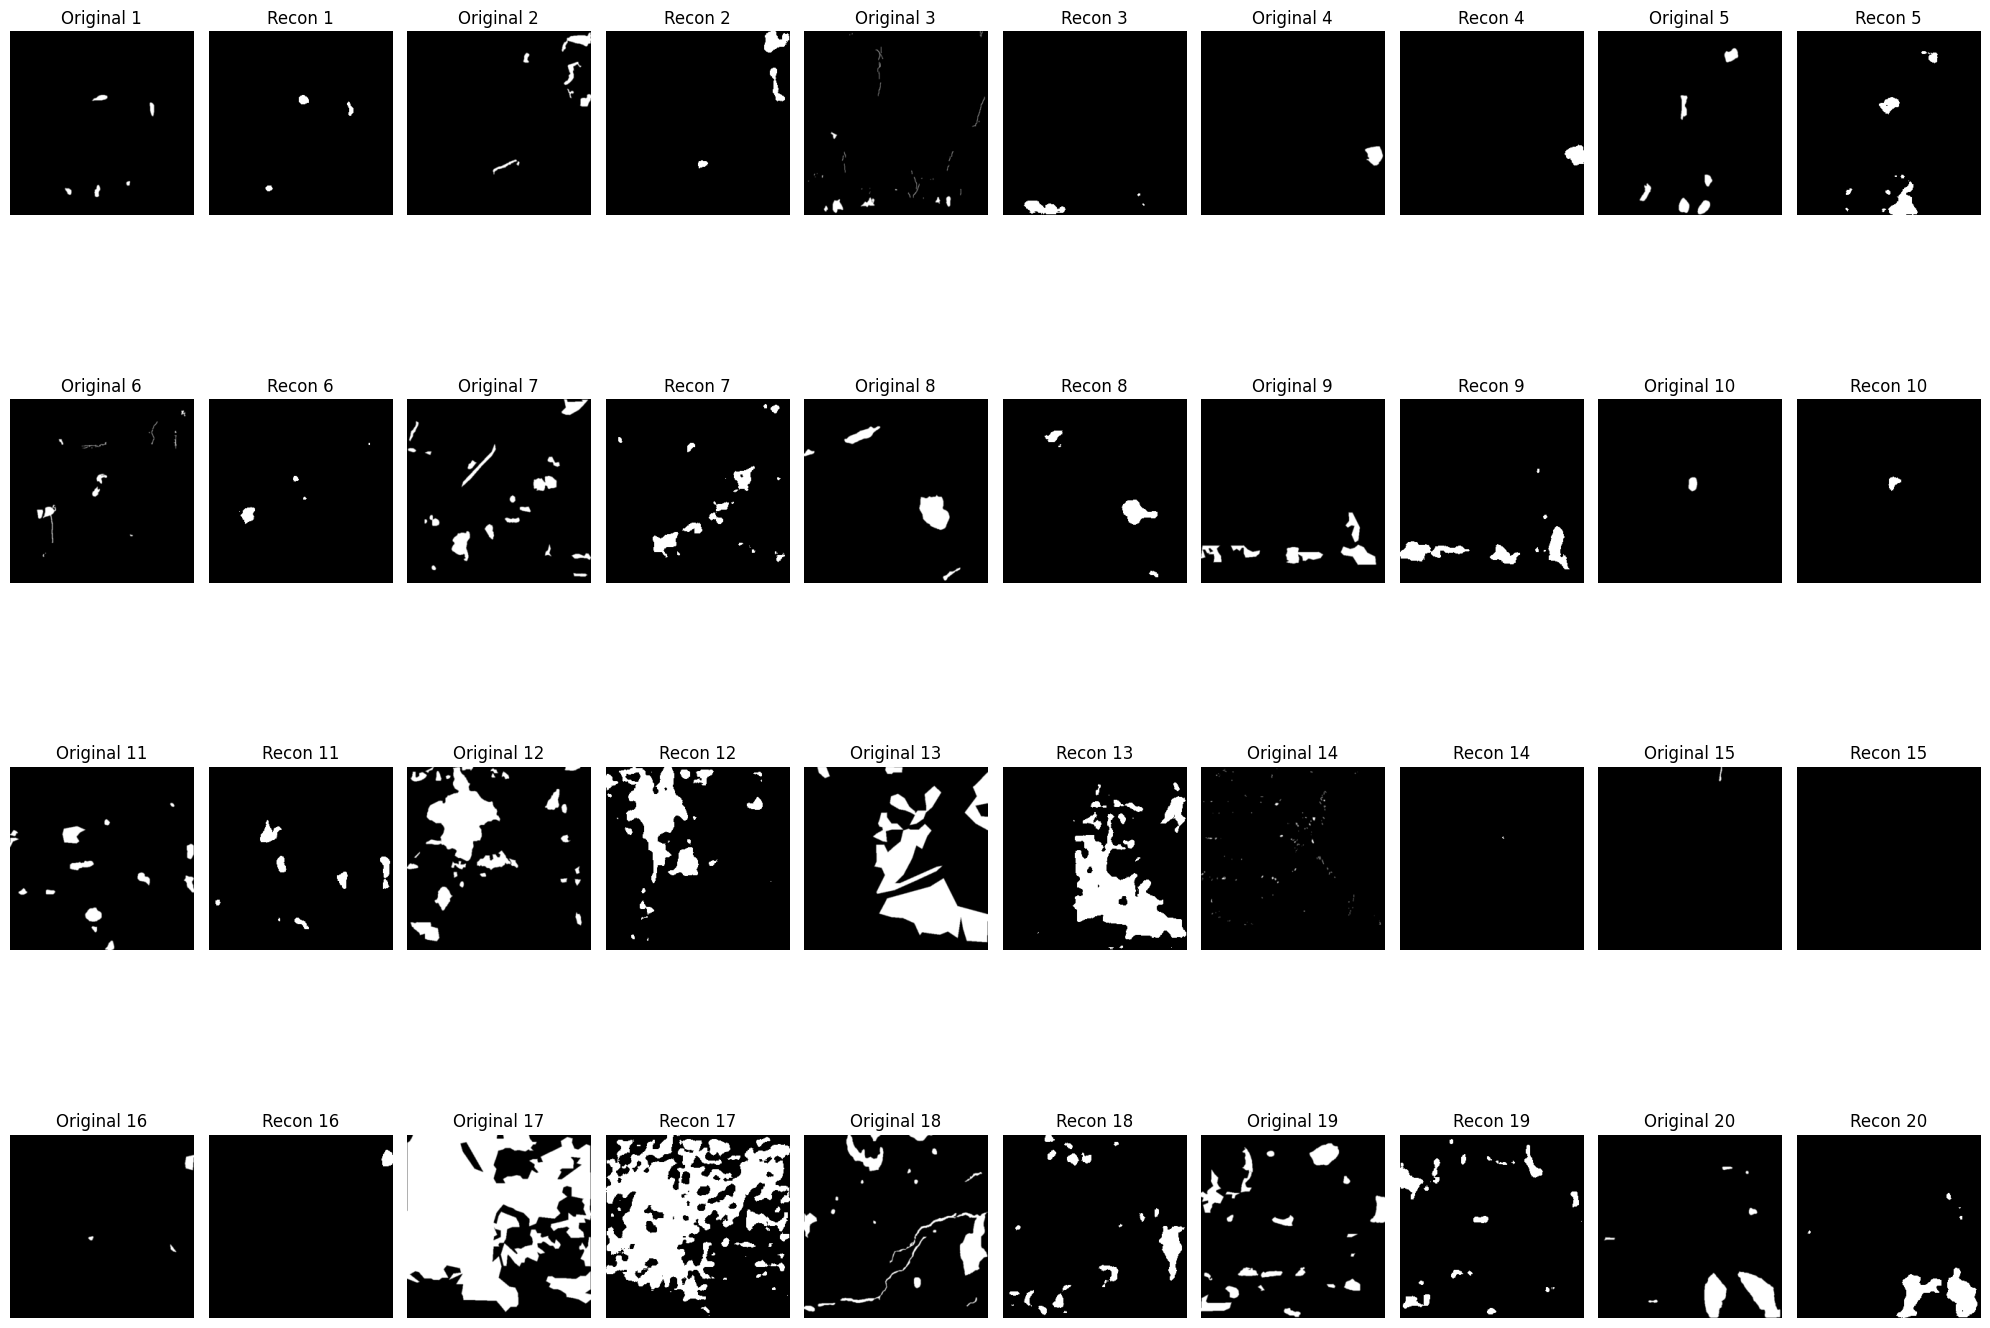

In [ ]:
model.eval()
test_loss = 0
with torch.no_grad():
    for labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        labels = labels.to(device)
        recon_labels, mu, logvar = model(labels)
        loss = loss_function(recon_labels, labels, mu, logvar)
        test_loss += loss.item()
avg_test_loss = test_loss / len(test_loader.dataset)
print(f"Test Loss: {avg_test_loss:.4f}")

import random

num_display = 20
cols = 5 
rows = (num_display + cols - 1) // cols

all_test_indices = list(range(len(test_dataset)))
selected_indices = random.sample(all_test_indices, num_display)

selected_images = torch.stack([test_dataset[i] for i in selected_indices]).to(device)

model.eval()
with torch.no_grad():
    recon_images, _, _ = model(selected_images)
    recon_images = (recon_images > 0.5).float()

selected_images_np = selected_images.cpu().squeeze(1).numpy()
recon_images_np = recon_images.cpu().squeeze(1).numpy()

fig, axes = plt.subplots(rows, cols * 2, figsize=(20, 4 * rows))

for i in range(num_display):
    row_idx = i // cols
    col_idx = (i % cols) * 2
    
    axes[row_idx, col_idx].imshow(selected_images_np[i], cmap='gray')
    axes[row_idx, col_idx].set_title(f"Original {i+1}")
    axes[row_idx, col_idx].axis('off')
    
    axes[row_idx, col_idx + 1].imshow(recon_images_np[i], cmap='gray')
    axes[row_idx, col_idx + 1].set_title(f"Recon {i+1}")
    axes[row_idx, col_idx + 1].axis('off')

plt.tight_layout()
plt.show()

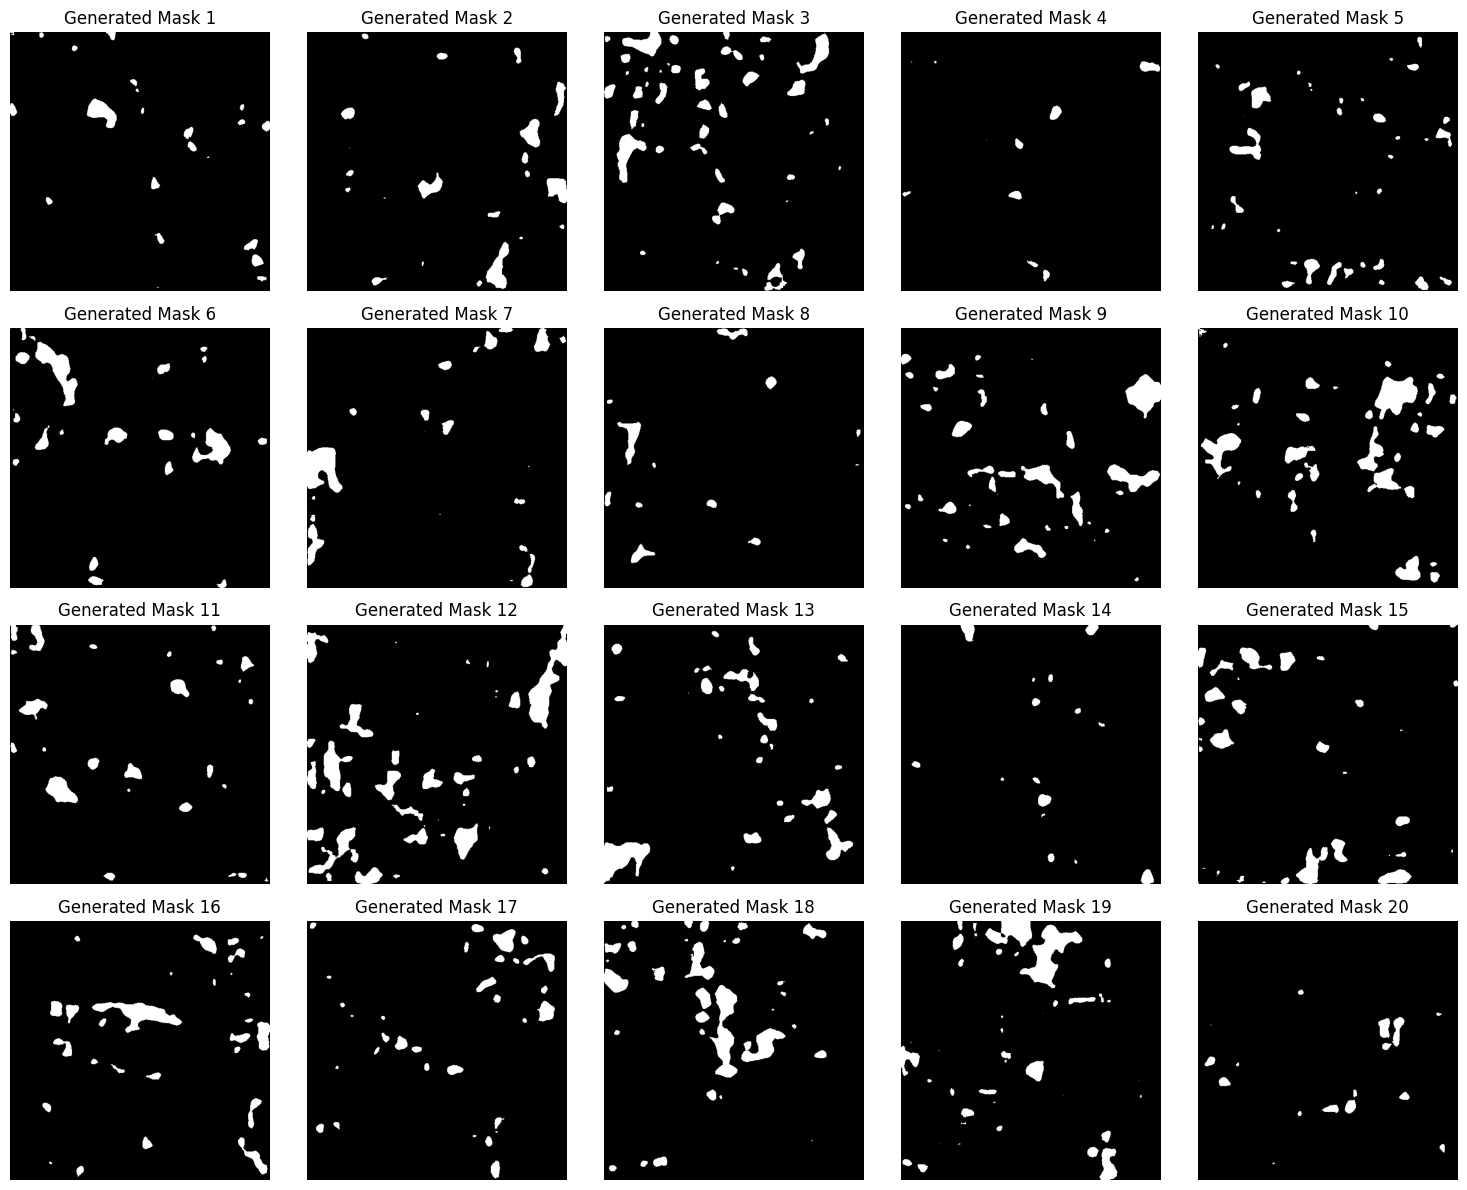

In [ ]:
import random
def generate_mask(model, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    latent_dim = getattr(model, 'latent_dim', 64)
    z = torch.randn(1, latent_dim).to(device)

    with torch.no_grad():
        r = model.decoder_input(z)
        generated_mask = model.decoder(r) 
        generated_mask = F.interpolate(generated_mask, size=(512, 512), mode='bilinear', align_corners=False)
        generated_mask = (generated_mask > 0.5).float()

    return generated_mask.cpu().squeeze()

num_masks = 20
masks_per_row = 5
fig, axes = plt.subplots(num_masks // masks_per_row, masks_per_row, figsize=(15, 12))
for i in range(num_masks):  
    seed = random.randint(0, 10000)
    generated_mask = generate_mask(model, seed=seed)
    axes[i // masks_per_row, i % masks_per_row].imshow(generated_mask.cpu(), cmap='gray')
    axes[i // masks_per_row, i % masks_per_row].set_title(f'Generated Mask {i+1}')
    axes[i // masks_per_row, i % masks_per_row].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
model_dir = os.path.join(os.path.dirname(os.getcwd()), 'model')
os.makedirs(model_dir, exist_ok=True)
save_path = os.path.join(model_dir, "VAE_learn_mask.pth")
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /Users/zyy/workspace/GNN-final/FinalProject/model/VAE_learn_mask.pth
